# 10 Machine Learning Models
### 5 Supervised Learning Models + 5 Unsupervised Learning Models

This notebook walks through 10 core Machine Learning algorithms using **scikit-learn**. For every model you will see:

- **A short explanation** — what the algorithm is, how it works internally, and when to use it
- **A "Before" visual** — what the raw data looks like *before* the model has learned anything
- **A "After" visual** — what the data/results look like *after* the model has been trained/applied
- **Evaluation metrics** — accuracy, R², silhouette score, etc. depending on the model type

**Supervised Models** (learn from labeled data):
1. Linear Regression
2. Logistic Regression
3. Decision Tree Classifier
4. Random Forest Classifier
5. Support Vector Machine (SVM)

**Unsupervised Models** (find structure in unlabeled data):
6. K-Means Clustering
7. Hierarchical (Agglomerative) Clustering
8. DBSCAN
9. Principal Component Analysis (PCA)
10. Gaussian Mixture Model (GMM)


In [1]:
# Common imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, r2_score, silhouette_score
)

np.random.seed(42)
sns.set_style("whitegrid")
print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Linear Regression

**What it is:** Linear Regression is the simplest **supervised** algorithm used for predicting a **continuous numeric value**. It assumes a straight-line (linear) relationship between the input features and the target.

**How it works:**
- It tries to fit a line (or hyperplane in higher dimensions) of the form `y = w1*x1 + w2*x2 + ... + b`
- The weights (`w`) and bias (`b`) are learned by minimizing the **Mean Squared Error (MSE)** between predicted and actual values (Ordinary Least Squares)
- Once trained, predictions are made by simply plugging feature values into the learned equation

**Strengths:** Fast, interpretable, works well when the relationship is genuinely linear.
**Weaknesses:** Poor performance on non-linear relationships; sensitive to outliers.
**Typical uses:** Sales forecasting, price prediction, risk scoring, trend analysis.

**Dataset:** Diabetes dataset — predicting disease progression one year after baseline, from patient measurements.

**Before vs After:** *Before* shows the raw relationship between BMI and disease progression with no model fitted. *After* shows the fitted regression line capturing that trend, plus a plot of actual vs. predicted values for the full multi-feature model.


Linear Regression Results (Diabetes dataset)
Mean Squared Error : 2900.19
R^2 Score           : 0.453


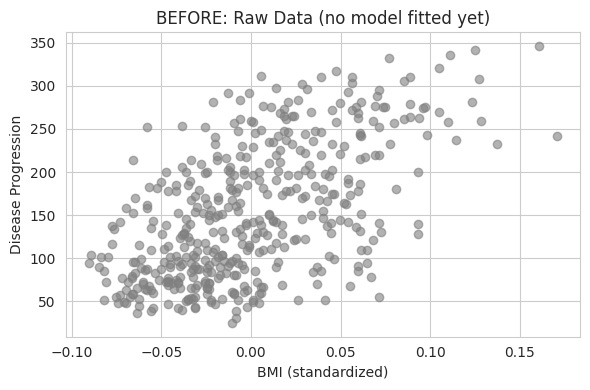

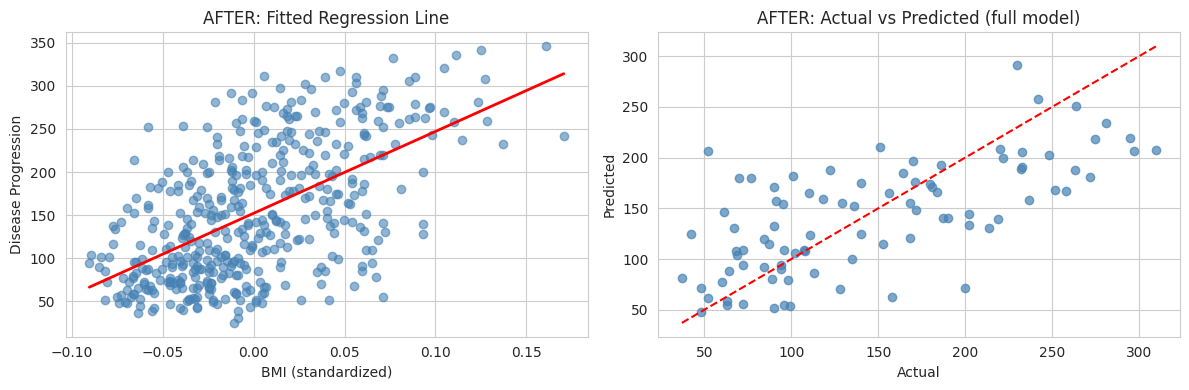

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
bmi = X[:, 2]  # BMI feature, for the illustrative before/after plot

# ---------- BEFORE: raw, unmodeled relationship ----------
plt.figure(figsize=(6,4))
plt.scatter(bmi, y, alpha=0.6, color="gray")
plt.xlabel("BMI (standardized)")
plt.ylabel("Disease Progression")
plt.title("BEFORE: Raw Data (no model fitted yet)")
plt.tight_layout()
plt.show()

# ---------- Train on ALL features ----------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Linear Regression Results (Diabetes dataset)")
print(f"Mean Squared Error : {mse:.2f}")
print(f"R^2 Score           : {r2:.3f}")

# ---------- AFTER: fitted line (single-feature, for visual clarity) + actual vs predicted ----------
simple_model = LinearRegression().fit(bmi.reshape(-1,1), y)
x_line = np.linspace(bmi.min(), bmi.max(), 100)
y_line = simple_model.predict(x_line.reshape(-1,1))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].scatter(bmi, y, alpha=0.6, color="steelblue")
axes[0].plot(x_line, y_line, color="red", linewidth=2)
axes[0].set_xlabel("BMI (standardized)"); axes[0].set_ylabel("Disease Progression")
axes[0].set_title("AFTER: Fitted Regression Line")

axes[1].scatter(y_test, y_pred, alpha=0.7, color="steelblue")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel("Actual"); axes[1].set_ylabel("Predicted")
axes[1].set_title("AFTER: Actual vs Predicted (full model)")
plt.tight_layout()
plt.show()


## 2. Logistic Regression

**What it is:** Despite the name, Logistic Regression is a **classification** algorithm, used to predict a **categorical outcome** (often binary: yes/no, malignant/benign).

**How it works:**
- Computes a weighted sum of the inputs, just like linear regression
- Passes that sum through the **sigmoid function**, which squashes it into a probability between 0 and 1
- If probability ≥ 0.5 → predicts class 1, otherwise class 0
- Weights are learned by minimizing **log-loss (cross-entropy)** via gradient descent

**Strengths:** Fast, interpretable (coefficients show feature influence), outputs calibrated probabilities.
**Weaknesses:** Assumes a roughly linear decision boundary; struggles with complex non-linear patterns.
**Typical uses:** Medical diagnosis, spam detection, churn prediction, credit approval.

**Dataset:** Breast Cancer Wisconsin dataset — classifying tumors as malignant or benign from cell measurements.

**Before vs After:** *Before* plots the two most informative features with no class information shown (as if the labels were unknown). *After* shows the same points colored by the model's prediction, alongside a confusion matrix summarizing correct vs incorrect predictions.


Logistic Regression Results (Breast Cancer dataset)
Accuracy: 0.974

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



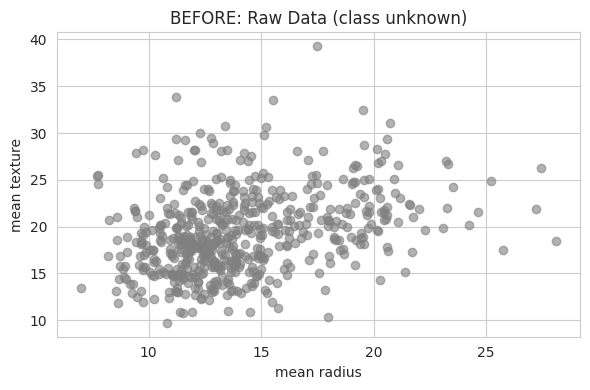

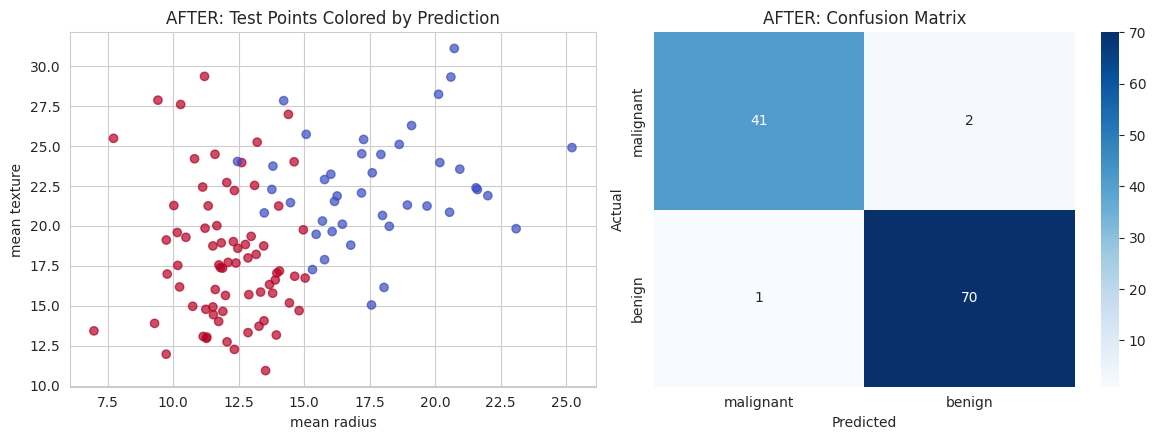

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()
X, y = data.data, data.target
f1, f2 = 0, 1  # mean radius, mean texture
feat_names = data.feature_names

# ---------- BEFORE: raw points, no labels shown ----------
plt.figure(figsize=(6,4))
plt.scatter(X[:, f1], X[:, f2], alpha=0.6, color="gray")
plt.xlabel(feat_names[f1]); plt.ylabel(feat_names[f2])
plt.title("BEFORE: Raw Data (class unknown)")
plt.tight_layout()
plt.show()

# ---------- Train ----------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train_s, y_train)
y_pred = log_reg.predict(X_test_s)

acc = accuracy_score(y_test, y_pred)
print("Logistic Regression Results (Breast Cancer dataset)")
print(f"Accuracy: {acc:.3f}\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# ---------- AFTER: predicted classes + confusion matrix ----------
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].scatter(X_test[:, f1], X_test[:, f2], c=y_pred, cmap="coolwarm", alpha=0.7)
axes[0].set_xlabel(feat_names[f1]); axes[0].set_ylabel(feat_names[f2])
axes[0].set_title("AFTER: Test Points Colored by Prediction")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=data.target_names, yticklabels=data.target_names)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title("AFTER: Confusion Matrix")
plt.tight_layout()
plt.show()


## 3. Decision Tree Classifier

**What it is:** A Decision Tree is a **supervised** model that predicts by learning a series of **if/else questions** about the features, forming a tree-like structure of decisions.

**How it works:**
- At each node, the algorithm picks the feature and threshold that best **splits** the data into purer subgroups (using metrics like **Gini impurity** or **entropy/information gain**)
- This splitting continues recursively until a stopping condition is met (e.g. `max_depth`, minimum samples per leaf)
- A new sample is classified by walking down the tree, following the branch matching its feature values, until it reaches a leaf (the predicted class)

**Strengths:** Easy to interpret and visualize, handles non-linear boundaries, needs little data preprocessing.
**Weaknesses:** Prone to overfitting if grown too deep; can be unstable (small data changes → different tree).
**Typical uses:** Credit scoring, medical decision support, any task where explainability matters.

**Dataset:** Iris dataset — classifying flowers into 3 species from petal/sepal measurements.

**Before vs After:** *Before* shows petal length vs. width with species unknown. *After* shows the same points colored by the tree's prediction, plus the actual tree structure showing the learned decision rules.


Decision Tree Classifier Results (Iris dataset)
Accuracy: 0.967

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



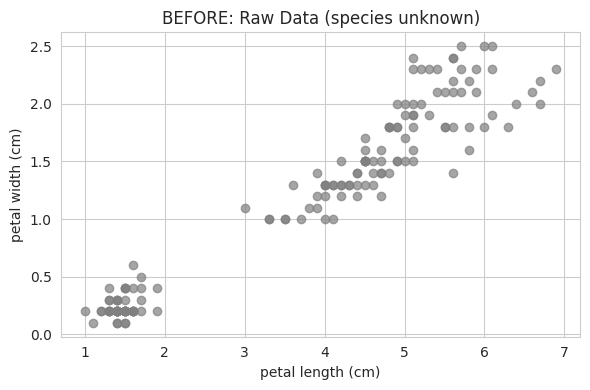

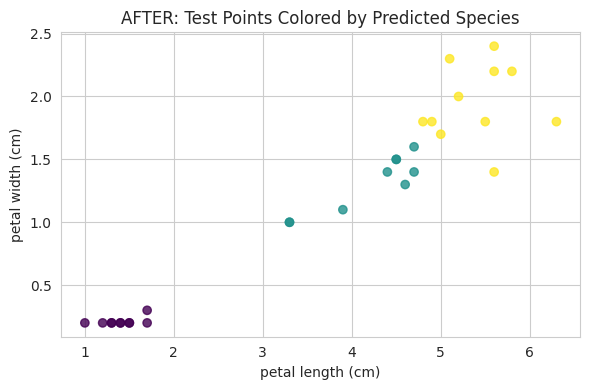

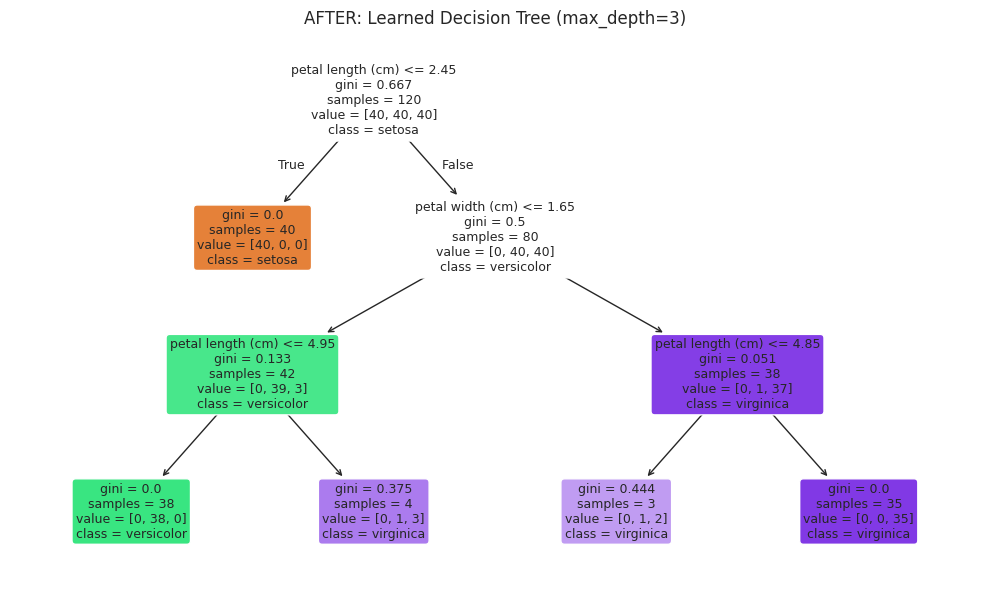

In [4]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

iris = load_iris()
X, y = iris.data, iris.target
f1, f2 = 2, 3  # petal length, petal width

# ---------- BEFORE ----------
plt.figure(figsize=(6,4))
plt.scatter(X[:, f1], X[:, f2], alpha=0.7, color="gray")
plt.xlabel(iris.feature_names[f1]); plt.ylabel(iris.feature_names[f2])
plt.title("BEFORE: Raw Data (species unknown)")
plt.tight_layout()
plt.show()

# ---------- Train ----------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train, y_train)
y_pred = tree_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Decision Tree Classifier Results (Iris dataset)")
print(f"Accuracy: {acc:.3f}\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# ---------- AFTER: predicted classes + tree structure ----------
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(X_test[:, f1], X_test[:, f2], c=y_pred, cmap="viridis", alpha=0.8)
ax.set_xlabel(iris.feature_names[f1]); ax.set_ylabel(iris.feature_names[f2])
ax.set_title("AFTER: Test Points Colored by Predicted Species")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plot_tree(tree_clf, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9)
plt.title("AFTER: Learned Decision Tree (max_depth=3)")
plt.tight_layout()
plt.show()


## 4. Random Forest Classifier

**What it is:** Random Forest is an **ensemble** method that builds **many Decision Trees** and combines their votes, giving much more robust predictions than any single tree.

**How it works:**
- Builds `n_estimators` decision trees, each trained on a random **bootstrap sample** of the data (bagging)
- At each split, each tree only considers a random **subset of features**, which decorrelates the trees
- For classification, the final prediction is the **majority vote** across all trees
- Because many trees are averaged, the model reduces the overfitting/variance problem that a single deep tree suffers from

**Strengths:** High accuracy, resistant to overfitting, provides feature importance, handles non-linear data well.
**Weaknesses:** Less interpretable than a single tree, slower to train/predict, larger memory footprint.
**Typical uses:** Fraud detection, recommendation systems, bioinformatics, any tabular data problem.

**Dataset:** Wine dataset — classifying wine samples into 3 cultivars based on chemical analysis.

**Before vs After:** *Before* shows two chemical features with no cultivar information. *After* shows the same points colored by the forest's prediction, plus which chemical features the forest found most useful.


Random Forest Classifier Results (Wine dataset)
Accuracy: 1.000

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



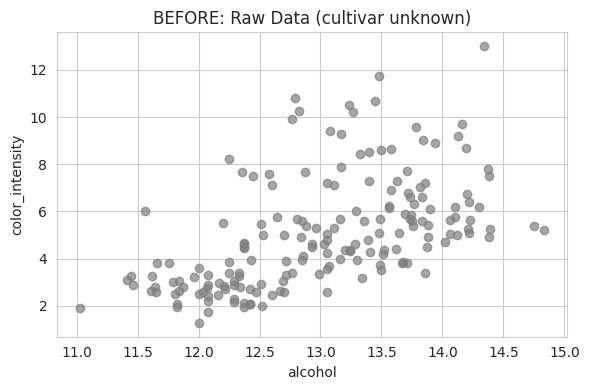

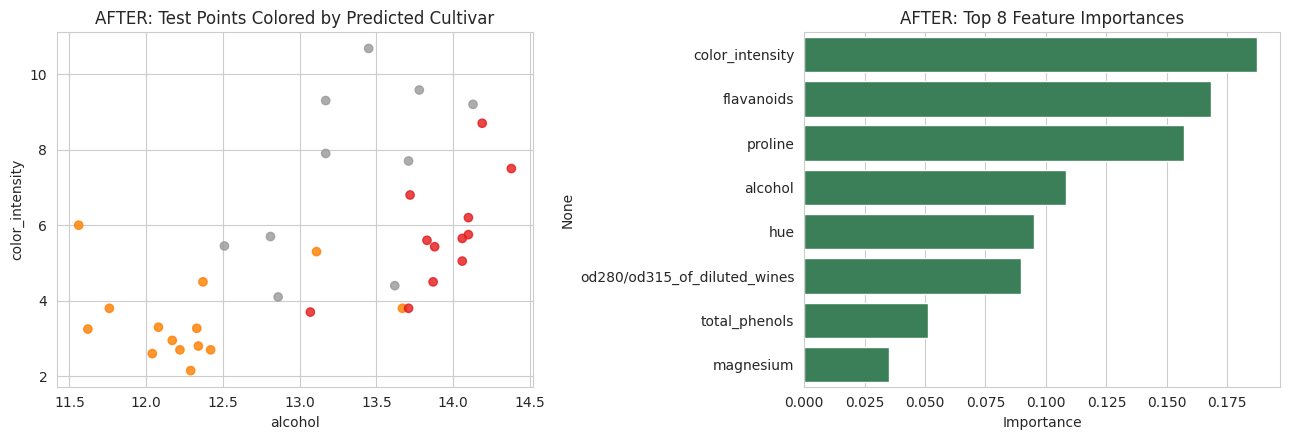

In [5]:
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier

wine = load_wine()
X, y = wine.data, wine.target
f1, f2 = 0, 9  # alcohol, color_intensity

# ---------- BEFORE ----------
plt.figure(figsize=(6,4))
plt.scatter(X[:, f1], X[:, f2], alpha=0.7, color="gray")
plt.xlabel(wine.feature_names[f1]); plt.ylabel(wine.feature_names[f2])
plt.title("BEFORE: Raw Data (cultivar unknown)")
plt.tight_layout()
plt.show()

# ---------- Train ----------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Random Forest Classifier Results (Wine dataset)")
print(f"Accuracy: {acc:.3f}\n")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

# ---------- AFTER: predicted classes + feature importances ----------
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
axes[0].scatter(X_test[:, f1], X_test[:, f2], c=y_pred, cmap="Set1", alpha=0.8)
axes[0].set_xlabel(wine.feature_names[f1]); axes[0].set_ylabel(wine.feature_names[f2])
axes[0].set_title("AFTER: Test Points Colored by Predicted Cultivar")

importances = pd.Series(rf_clf.feature_importances_, index=wine.feature_names).sort_values(ascending=False)[:8]
sns.barplot(x=importances.values, y=importances.index, color="seagreen", ax=axes[1])
axes[1].set_title("AFTER: Top 8 Feature Importances")
axes[1].set_xlabel("Importance")
plt.tight_layout()
plt.show()


## 5. Support Vector Machine (SVM)

**What it is:** SVM is a **supervised** classifier that finds the **optimal boundary (hyperplane)** that separates classes with the **maximum margin** between the closest points of each class (the "support vectors").

**How it works:**
- In simple cases, it looks for a straight line/plane that best separates the classes
- When data isn't linearly separable, the **kernel trick** (e.g. RBF kernel) implicitly projects data into a higher-dimensional space where a linear separator *does* exist
- Only the points closest to the boundary ("support vectors") matter for defining it — this makes SVMs memory-efficient at prediction time
- The `C` parameter controls the trade-off between a wide margin and classifying every training point correctly

**Strengths:** Effective in high-dimensional spaces, works well even with a clear margin of separation.
**Weaknesses:** Slower to train on large datasets, less interpretable, needs careful kernel/parameter tuning.
**Typical uses:** Image classification, handwriting/digit recognition, text categorization, bioinformatics.

**Dataset:** Digits dataset — recognizing handwritten digits (0–9) from 8×8 pixel images.

**Before vs After:** *Before* shows raw digit images with no labels attached. *After* shows the same images with the SVM's predicted digit label on each.


SVM (RBF kernel) Results (Digits dataset)
Accuracy: 0.981


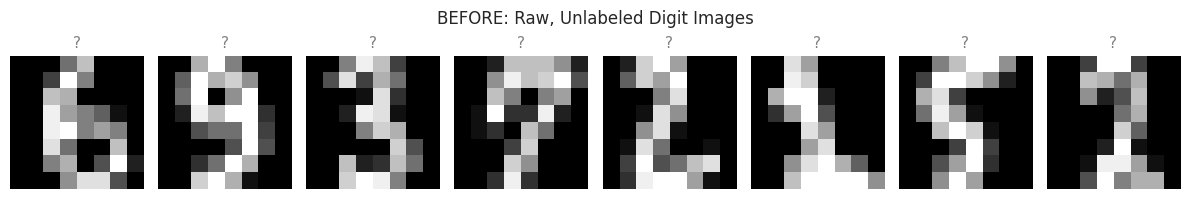

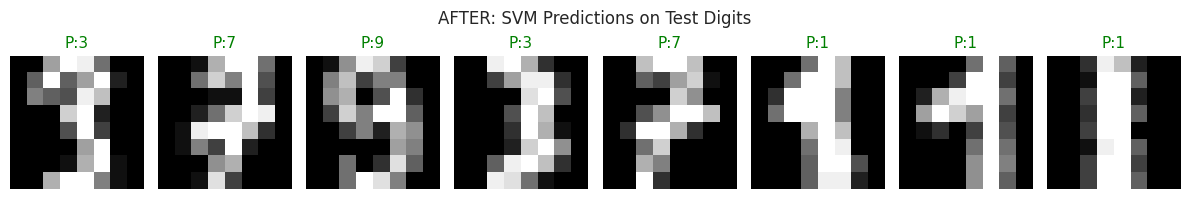

In [6]:
from sklearn.datasets import load_digits
from sklearn.svm import SVC

digits = load_digits()
X, y = digits.data, digits.target

# ---------- BEFORE: unlabeled digit images ----------
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X), 8, replace=False)

fig, axes = plt.subplots(1, 8, figsize=(12,2))
for i, ax in zip(sample_idx, axes):
    ax.imshow(X[i].reshape(8,8), cmap='gray')
    ax.set_title("?", fontsize=11, color="gray")
    ax.axis('off')
fig.suptitle("BEFORE: Raw, Unlabeled Digit Images")
plt.tight_layout()
plt.show()

# ---------- Train ----------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

svm_clf = SVC(kernel='rbf', gamma='scale', C=10)
svm_clf.fit(X_train_s, y_train)
y_pred = svm_clf.predict(X_test_s)

acc = accuracy_score(y_test, y_pred)
print("SVM (RBF kernel) Results (Digits dataset)")
print(f"Accuracy: {acc:.3f}")

# ---------- AFTER: same-style images now with predicted labels ----------
fig, axes = plt.subplots(1, 8, figsize=(12,2))
test_sample_idx = rng.choice(len(X_test), 8, replace=False)
for i, ax in zip(test_sample_idx, axes):
    ax.imshow(X_test[i].reshape(8,8), cmap='gray')
    ax.set_title(f"P:{y_pred[i]}", fontsize=11, color="green" if y_pred[i]==y_test[i] else "red")
    ax.axis('off')
fig.suptitle("AFTER: SVM Predictions on Test Digits")
plt.tight_layout()
plt.show()


## 6. K-Means Clustering

**What it is:** K-Means is an **unsupervised** algorithm that groups data into `k` clusters based purely on feature similarity — no labels are used at all.

**How it works:**
1. Randomly place `k` cluster centers ("centroids")
2. Assign every point to its **nearest centroid** (by Euclidean distance)
3. Move each centroid to the **mean** of the points assigned to it
4. Repeat steps 2–3 until the centroids stop moving (convergence)

**Strengths:** Simple, fast, scales well to large datasets.
**Weaknesses:** You must choose `k` in advance; assumes roughly spherical, similarly-sized clusters; sensitive to initialization and outliers.
**Typical uses:** Customer segmentation, market research, image compression, document clustering.

**Dataset:** Iris dataset (features only — species labels are hidden from the algorithm).

**Before vs After:** *Before* shows all points in a single color — the algorithm has no idea groups exist yet. *After* shows the same points colored by the cluster K-Means discovered on its own.


K-Means Clustering Results (Iris dataset)
Silhouette Score: 0.553
Cluster sizes: [62 50 38]


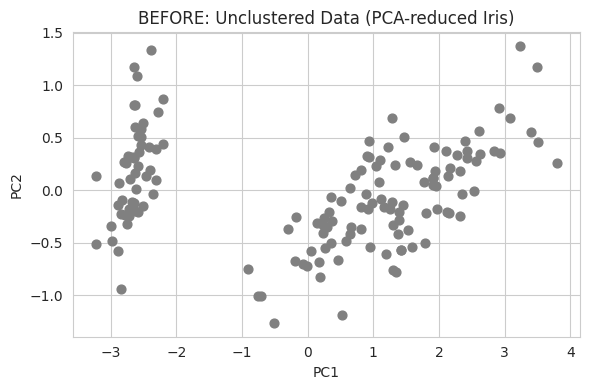

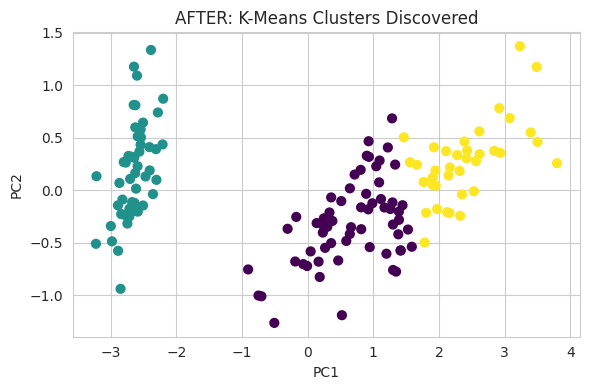

In [7]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA as PCA_viz

iris = load_iris()
X = iris.data
X_2d = PCA_viz(n_components=2).fit_transform(X)

# ---------- BEFORE: no clusters yet ----------
plt.figure(figsize=(6,4))
plt.scatter(X_2d[:,0], X_2d[:,1], color="gray", s=40)
plt.title("BEFORE: Unclustered Data (PCA-reduced Iris)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# ---------- Fit K-Means ----------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

sil = silhouette_score(X, clusters)
print("K-Means Clustering Results (Iris dataset)")
print(f"Silhouette Score: {sil:.3f}")
print(f"Cluster sizes: {np.bincount(clusters)}")

# ---------- AFTER: clusters discovered ----------
plt.figure(figsize=(6,4))
plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters, cmap='viridis', s=40)
plt.title("AFTER: K-Means Clusters Discovered")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()


## 7. Hierarchical (Agglomerative) Clustering

**What it is:** An **unsupervised** clustering method that builds a hierarchy of clusters from the bottom up, producing a tree (**dendrogram**) rather than a fixed number of flat clusters.

**How it works:**
1. Start with **every point as its own cluster**
2. Repeatedly **merge the two closest clusters** (distance measured by a linkage method, e.g. `ward`, which minimizes the increase in within-cluster variance)
3. Continue merging until only one cluster remains, recording the merge order/distances
4. "Cut" the resulting dendrogram at a chosen height to get any desired number of clusters

**Strengths:** No need to pre-specify `k` (can decide after seeing the dendrogram); captures nested cluster structure.
**Weaknesses:** Computationally expensive on large datasets (O(n²) or worse); merge decisions are irreversible.
**Typical uses:** Gene expression analysis, taxonomy/organizational grouping, document/topic hierarchies.

**Dataset:** Wine dataset (scaled chemical measurements, labels hidden from the algorithm).

**Before vs After:** *Before* shows all wine samples as one undifferentiated group. *After* shows the clusters formed once the hierarchy is cut into 3 groups, plus the dendrogram showing how those merges happened.


Agglomerative Clustering Results (Wine dataset)
Silhouette Score: 0.277
Cluster sizes: [58 56 64]


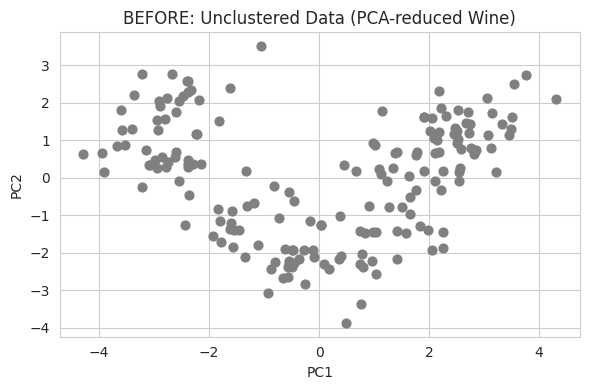

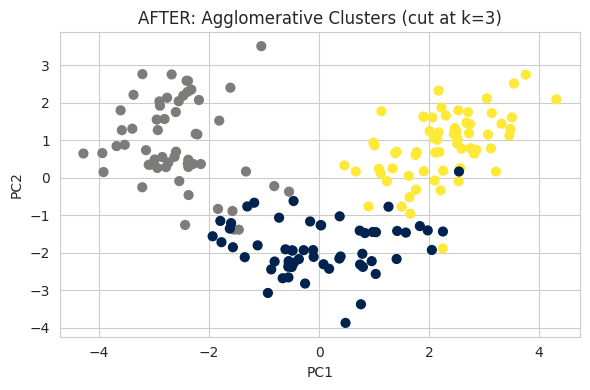

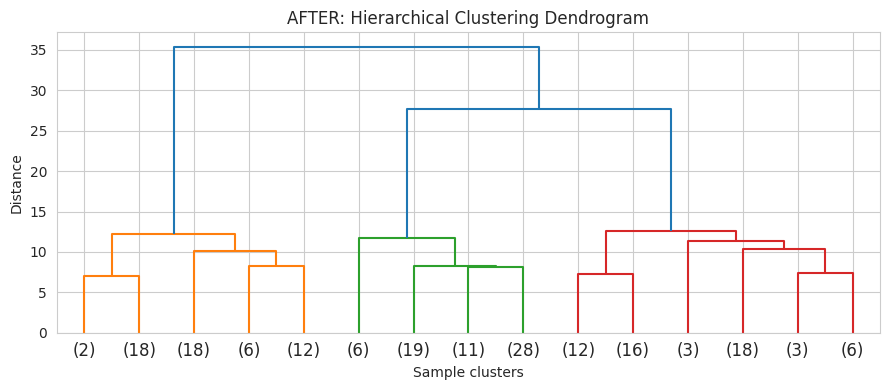

In [8]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

wine = load_wine()
X = StandardScaler().fit_transform(wine.data)
X_2d = PCA_viz(n_components=2).fit_transform(X)

# ---------- BEFORE ----------
plt.figure(figsize=(6,4))
plt.scatter(X_2d[:,0], X_2d[:,1], color="gray", s=40)
plt.title("BEFORE: Unclustered Data (PCA-reduced Wine)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# ---------- Fit ----------
agg = AgglomerativeClustering(n_clusters=3)
clusters = agg.fit_predict(X)

sil = silhouette_score(X, clusters)
print("Agglomerative Clustering Results (Wine dataset)")
print(f"Silhouette Score: {sil:.3f}")
print(f"Cluster sizes: {np.bincount(clusters)}")

# ---------- AFTER: clusters + dendrogram ----------
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(X_2d[:,0], X_2d[:,1], c=clusters, cmap='cividis', s=40)
ax.set_title("AFTER: Agglomerative Clusters (cut at k=3)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

Z = linkage(X, method='ward')
plt.figure(figsize=(9,4))
dendrogram(Z, truncate_mode='lastp', p=15)
plt.title("AFTER: Hierarchical Clustering Dendrogram")
plt.xlabel("Sample clusters")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


## 8. DBSCAN

**What it is:** DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an **unsupervised** algorithm that finds clusters of arbitrary shape based on **density**, and automatically flags sparse points as **noise/outliers**.

**How it works:**
- For each point, look within radius **`eps`** — if it has at least **`min_samples`** neighbors, it's a **core point**
- Core points that are close to each other are merged into the same cluster
- Points that fall within `eps` of a core point but don't have enough neighbors themselves are **border points**
- Points with no nearby core points are labeled **noise (-1)** — not forced into any cluster

**Strengths:** No need to specify the number of clusters; finds non-spherical (e.g. moon or ring-shaped) clusters; naturally identifies outliers.
**Weaknesses:** Sensitive to `eps`/`min_samples` choice; struggles when clusters have very different densities.
**Typical uses:** Anomaly/fraud detection, spatial data analysis (e.g. GPS trip clustering), image segmentation.

**Dataset:** Synthetic two-moon dataset — deliberately non-spherical, to show where K-Means-style clustering would fail but density-based clustering succeeds.

**Before vs After:** *Before* shows the raw crescent-shaped point clouds with no grouping. *After* shows DBSCAN correctly separating the two moons by density, with any noise points marked separately.


DBSCAN Results (synthetic moon-shaped data)
Estimated clusters: 2
Noise points: 0


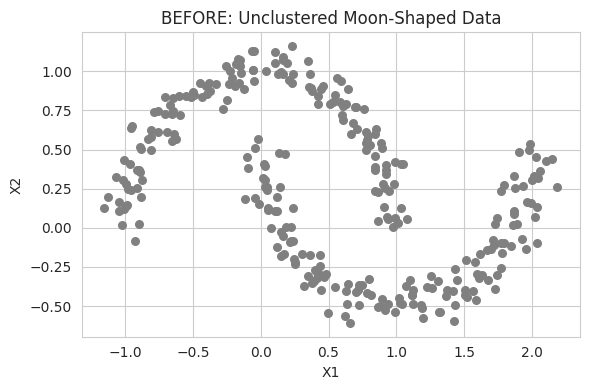

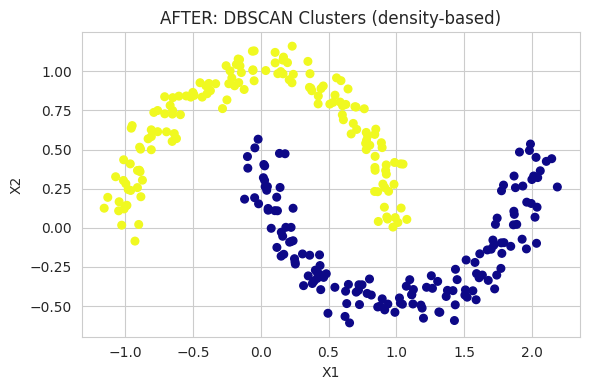

In [9]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, _ = make_moons(n_samples=300, noise=0.07, random_state=42)

# ---------- BEFORE ----------
plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], color="gray", s=30)
plt.title("BEFORE: Unclustered Moon-Shaped Data")
plt.xlabel("X1"); plt.ylabel("X2")
plt.tight_layout()
plt.show()

# ---------- Fit ----------
db = DBSCAN(eps=0.2, min_samples=5)
clusters = db.fit_predict(X)

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
print("DBSCAN Results (synthetic moon-shaped data)")
print(f"Estimated clusters: {n_clusters}")
print(f"Noise points: {n_noise}")

# ---------- AFTER ----------
plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c=clusters, cmap='plasma', s=30)
plt.title("AFTER: DBSCAN Clusters (density-based)")
plt.xlabel("X1"); plt.ylabel("X2")
plt.tight_layout()
plt.show()


## 9. Principal Component Analysis (PCA)

**What it is:** PCA is an **unsupervised dimensionality reduction** technique — it compresses many correlated features into a smaller number of new, uncorrelated features ("principal components") while preserving as much variance (information) as possible.

**How it works:**
1. Standardizes/centers the data
2. Computes the **covariance matrix** of the features
3. Finds its **eigenvectors/eigenvalues** — the eigenvectors become the new axes (principal components), ordered by how much variance (eigenvalue) they explain
4. Projects the data onto the top `n_components` axes, discarding the axes that explain the least variance

**Strengths:** Great for visualization (reducing to 2D/3D), speeds up downstream models, reduces noise/redundancy.
**Weaknesses:** New components are linear combinations of original features and lose direct interpretability; only captures linear structure.
**Typical uses:** Data visualization, noise reduction, preprocessing before clustering/classification, compression.

**Dataset:** Digits dataset — each image has 64 pixel-intensity features (8×8 pixels).

**Before vs After:** *Before* plots the data using two **raw pixel** features directly (arbitrary, largely unstructured). *After* plots the same data using the top 2 **principal components**, which capture the dominant patterns and separate the digit classes far more clearly.


PCA Results (Digits dataset)
Original dimensions : 64
Reduced dimensions  : 2
Explained variance ratio: [0.14890594 0.13618771]
Total variance captured : 0.285


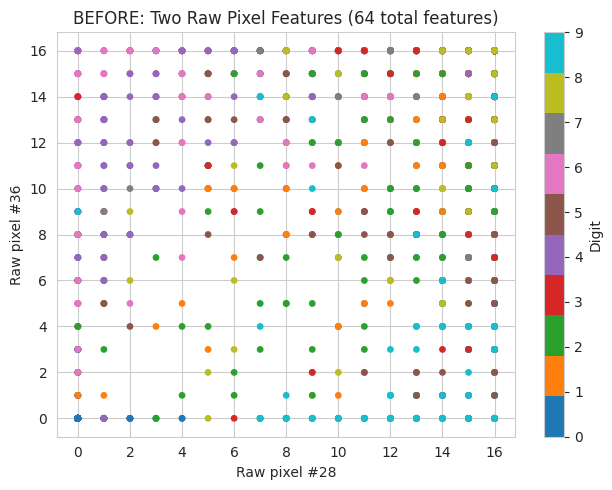

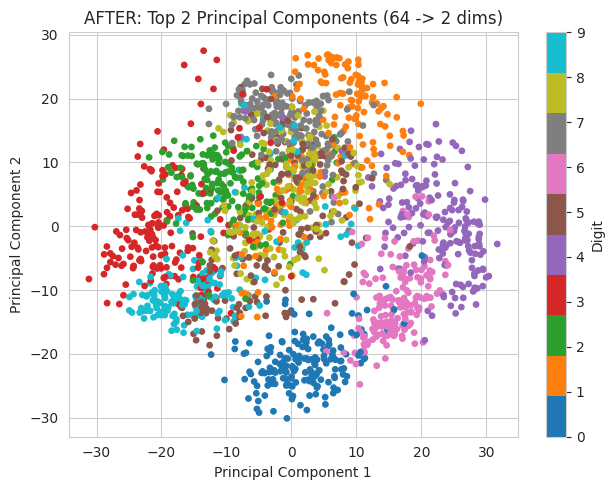

In [10]:
from sklearn.decomposition import PCA

digits = load_digits()
X, y = digits.data, digits.target

# ---------- BEFORE: two raw pixel features (uninformative on their own) ----------
plt.figure(figsize=(6.5,5))
sc = plt.scatter(X[:, 28], X[:, 36], c=y, cmap='tab10', s=15)
plt.colorbar(sc, label='Digit')
plt.title("BEFORE: Two Raw Pixel Features (64 total features)")
plt.xlabel("Raw pixel #28"); plt.ylabel("Raw pixel #36")
plt.tight_layout()
plt.show()

# ---------- Fit PCA ----------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("PCA Results (Digits dataset)")
print(f"Original dimensions : {X.shape[1]}")
print(f"Reduced dimensions  : {X_pca.shape[1]}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance captured : {pca.explained_variance_ratio_.sum():.3f}")

# ---------- AFTER: top 2 principal components ----------
plt.figure(figsize=(6.5,5))
sc = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab10', s=15)
plt.colorbar(sc, label='Digit')
plt.title("AFTER: Top 2 Principal Components (64 -> 2 dims)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()


## 10. Gaussian Mixture Model (GMM)

**What it is:** GMM is an **unsupervised, probabilistic** clustering method that assumes the data is generated from a mixture of several **Gaussian (normal) distributions**, each representing one cluster.

**How it works:**
- Assumes there are `k` underlying Gaussian distributions (each with its own mean and covariance)
- Uses the **Expectation-Maximization (EM) algorithm**:
  - **E-step:** estimate the probability that each point belongs to each Gaussian
  - **M-step:** update each Gaussian's mean/covariance/weight to better fit the points assigned to it
  - Repeat until convergence
- Unlike K-Means (hard assignment), GMM gives **soft/probabilistic assignments** — a point can partially belong to multiple clusters

**Strengths:** Captures elliptical (not just spherical) clusters, gives probability of membership, more flexible than K-Means.
**Weaknesses:** Still requires choosing the number of components; can converge to a local optimum; sensitive to initialization.
**Typical uses:** Speaker/voice identification, anomaly detection, image segmentation, density estimation.

**Dataset:** Synthetic blob dataset with 4 distinct groups.

**Before vs After:** *Before* shows the raw blobs with no group information. *After* shows the points colored by the Gaussian component GMM assigned them to, with the learned cluster centers marked.


Gaussian Mixture Model Results (synthetic blobs)
Silhouette Score: 0.845
Converged: True
Cluster sizes: [100 100 100 100]


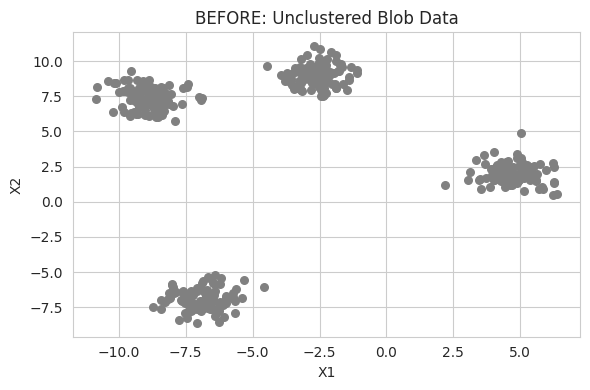

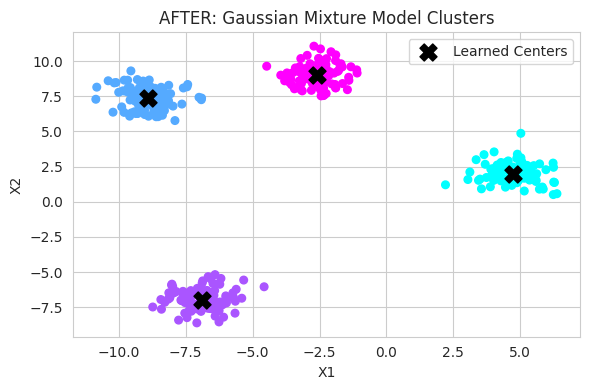

In [11]:
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

X, y_true = make_blobs(n_samples=400, centers=4, cluster_std=0.75, random_state=42)

# ---------- BEFORE ----------
plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], color="gray", s=30)
plt.title("BEFORE: Unclustered Blob Data")
plt.xlabel("X1"); plt.ylabel("X2")
plt.tight_layout()
plt.show()

# ---------- Fit ----------
gmm = GaussianMixture(n_components=4, random_state=42)
clusters = gmm.fit_predict(X)

sil = silhouette_score(X, clusters)
print("Gaussian Mixture Model Results (synthetic blobs)")
print(f"Silhouette Score: {sil:.3f}")
print(f"Converged: {gmm.converged_}")
print(f"Cluster sizes: {np.bincount(clusters)}")

# ---------- AFTER ----------
plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c=clusters, cmap='cool', s=30)
plt.scatter(gmm.means_[:,0], gmm.means_[:,1], c='black', marker='X', s=150, label='Learned Centers')
plt.title("AFTER: Gaussian Mixture Model Clusters")
plt.xlabel("X1"); plt.ylabel("X2")
plt.legend()
plt.tight_layout()
plt.show()


## Summary

| # | Model | Type | Category | Dataset |
|---|-------|------|----------|---------|
| 1 | Linear Regression | Supervised | Regression | Diabetes |
| 2 | Logistic Regression | Supervised | Classification | Breast Cancer |
| 3 | Decision Tree Classifier | Supervised | Classification | Iris |
| 4 | Random Forest Classifier | Supervised | Classification (Ensemble) | Wine |
| 5 | Support Vector Machine (SVM) | Supervised | Classification | Digits |
| 6 | K-Means Clustering | Unsupervised | Clustering (centroid-based) | Iris |
| 7 | Agglomerative Clustering | Unsupervised | Clustering (hierarchical) | Wine |
| 8 | DBSCAN | Unsupervised | Clustering (density-based) | Moons (synthetic) |
| 9 | PCA | Unsupervised | Dimensionality Reduction | Digits |
| 10 | Gaussian Mixture Model | Unsupervised | Clustering (probabilistic) | Blobs (synthetic) |

**Key takeaway:** Supervised models learn a mapping from features to a known target (label or number) and are evaluated against ground truth. Unsupervised models find structure in data with no labels at all, and are typically evaluated with internal metrics like the silhouette score, or simply by visual inspection of the discovered structure — as shown in every "Before vs After" pair above.
